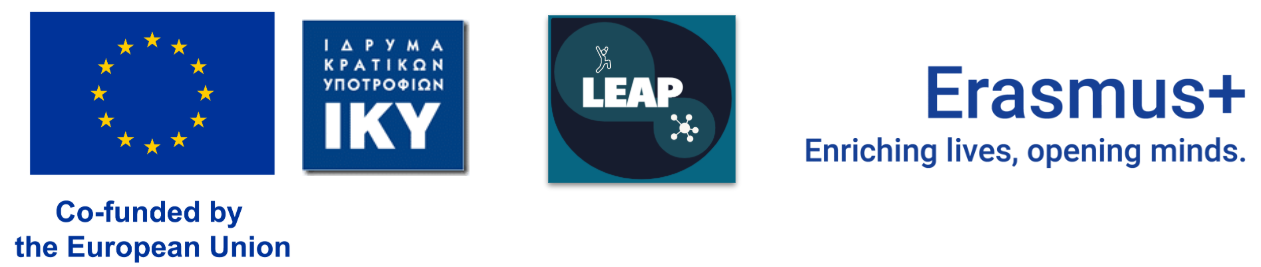

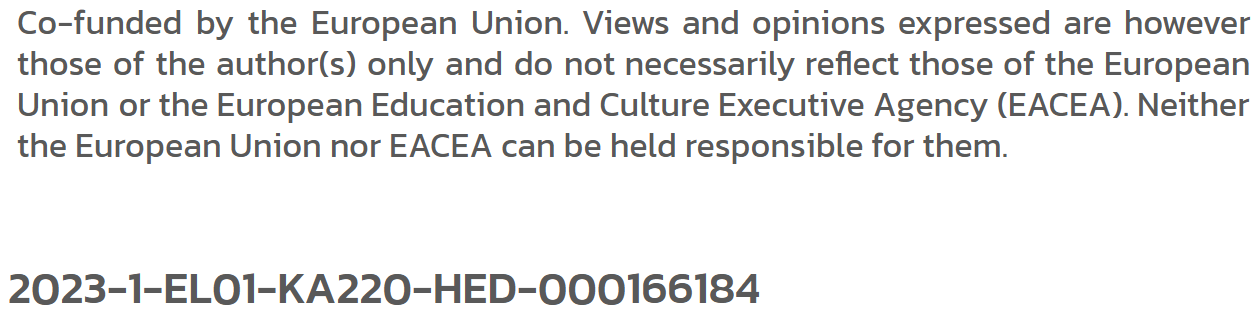

# Final Project, Option 1: Where does your CNN make its mistakes?

Software that reads handwritten numbers, such as postcodes on envelopes or account numbers on paper forms, must be judged not only on how often it is right but on where it goes wrong, because a confident misreading carries a real cost. In this project you build such a model and study the mistakes it makes.

In this project you build a convolutional neural network that recognises handwritten digits, then you study the mistakes it makes.

**Central question:** where does your CNN make its mistakes, and does one change to the model move them?

The data set is MNIST: 70,000 images of handwritten digits, each 28 by 28 pixels in greyscale, labelled 0 to 9. You download it yourself in the next cell.

This project draws on two earlier modules. In Module 5, we built and trained dense neural networks in Keras. In Module 6, we added convolutional layers, used Dropout and EarlyStopping to control overfitting, and read a confusion matrix to see which classes a model mixes up. Here you bring those skills together on a larger, more varied data set.

**How this notebook is organised.** The cells in Part A are already written for you. They handle the import, the download, and the reshaping that turns each flat row of 784 numbers back into a 28 by 28 image. From Part B onward, the cells are yours to complete. Each one carries comments describing what to do, along with a few hints, but not the finished code. Work through them in order.

Training on the full data set may take a few minutes per epoch on a laptop without a graphics card. This is expected.

## Part A. Setup and data

We start with the imports. This cell loads everything the notebook needs, so we run it once at the top.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import keras
from keras import layers

### Loading the data

We download MNIST from OpenML. The call returns the images in `X` as 70,000 rows of 784 numbers, and the labels in `y` as text. We convert the labels to integers so the model can work with them. The download runs once and may take a moment.

In [15]:
X, y = fetch_openml("mnist_784", version=1, as_frame=False, return_X_y=True)
y = y.astype(int)

print("Images:", X.shape)
print("Labels:", y.shape, "| classes:", np.unique(y))

Images: (70000, 784)
Labels: (70000,) | classes: [0 1 2 3 4 5 6 7 8 9]


### Preparing the images

Each row of `X` is one image flattened into a line of 784 numbers. We reshape every row back into a 28 by 28 image with a single greyscale channel, and we scale the pixel values from the range 0 to 255 down to the range 0 to 1, which helps the network train. We then split the data into a training set and a test set, keeping the class balance with `stratify`, as we did in Module 3.

In [16]:
X = X.reshape(-1, 28, 28, 1).astype("float32") / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training images:", X_train.shape)
print("Test images:    ", X_test.shape)

# If training is slow on your machine, you may work with a smaller sample
# while you get everything running, for example:
#   X_train, y_train = X_train[:10000], y_train[:10000]

Training images: (56000, 28, 28, 1)
Test images:     (14000, 28, 28, 1)


### A first look at the images

Before modelling, we look at a few training images with their labels, to confirm the data loaded correctly.

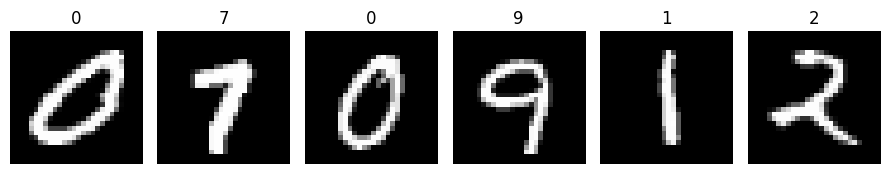

In [17]:
fig, axes = plt.subplots(1, 6, figsize=(9, 2))
for ax, image, label in zip(axes, X_train, y_train):
    ax.imshow(image.reshape(28, 28), cmap="gray")
    ax.set_title(str(label))
    ax.axis("off")
plt.tight_layout()
plt.show()

## Part B. Build and train your network

From here on, the cells are yours to complete.

First, build a convolutional neural network with the Keras Sequential API, the same style you used in Module 6. Recall the shape of one image: 28 by 28, with one channel.

In [18]:
keras.utils.set_random_seed(42)

model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

### Compile the model

Compiling sets the optimiser, the loss function, and the metric to watch during training.

In [19]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Train the model

Train the network, watching how it performs on data it has not learnt from. `EarlyStopping` halts training once the validation loss stops improving, so you do not waste time or overfit.

In [20]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    callbacks=[early_stopping]
)

Epoch 1/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.9092 - loss: 0.3206 - val_accuracy: 0.9636 - val_loss: 0.1290
Epoch 2/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.9683 - loss: 0.1088 - val_accuracy: 0.9730 - val_loss: 0.0858
Epoch 3/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.9768 - loss: 0.0783 - val_accuracy: 0.9786 - val_loss: 0.0676
Epoch 4/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.9812 - loss: 0.0616 - val_accuracy: 0.9805 - val_loss: 0.0611
Epoch 5/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.9835 - loss: 0.0530 - val_accuracy: 0.9825 - val_loss: 0.0542
Epoch 6/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.9855 - loss: 0.0444 - val_accuracy: 0.9830 - val_loss: 0.0522
Epoch 7/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.9879 - loss: 0.0380 - val_accuracy: 0.9861 - val_loss: 0.0494
Epoch 8/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.9886 - loss: 0.0347 - 

### Learning curves

Plot the training and validation loss across the epochs. A validation curve that flattens or turns upward while the training curve keeps falling is a sign of overfitting.

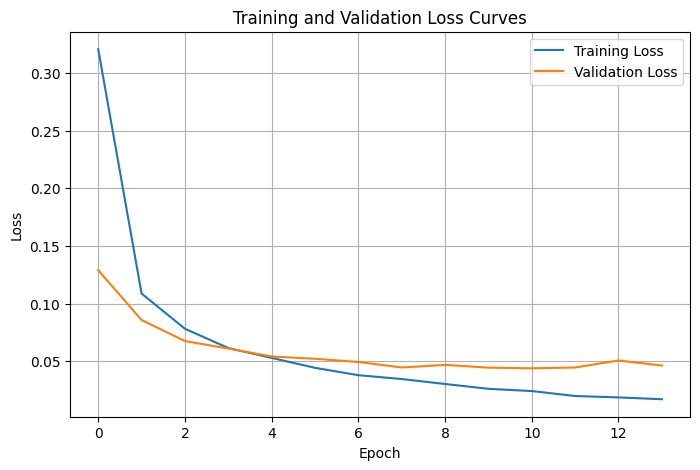

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

## Part C. Read the mistakes

Now measure how well the model does on the test set, the images it has never seen. This gives a reliable estimate of how it will perform on new images.

In [22]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

y_pred_probs = model.predict(X_test)
y_pred = y_pred_probs.argmax(axis=1)

438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9863 - loss: 0.0488
Test Accuracy: 0.9863
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


### The confusion matrix

The confusion matrix is where you answer the first half of the central question: where the mistakes are. Read it by rows. Each row is a true digit, each column is the digit the model predicted. The diagonal holds the correct predictions; every off-diagonal cell is a mistake, and its position tells you which digit was mistaken for which.

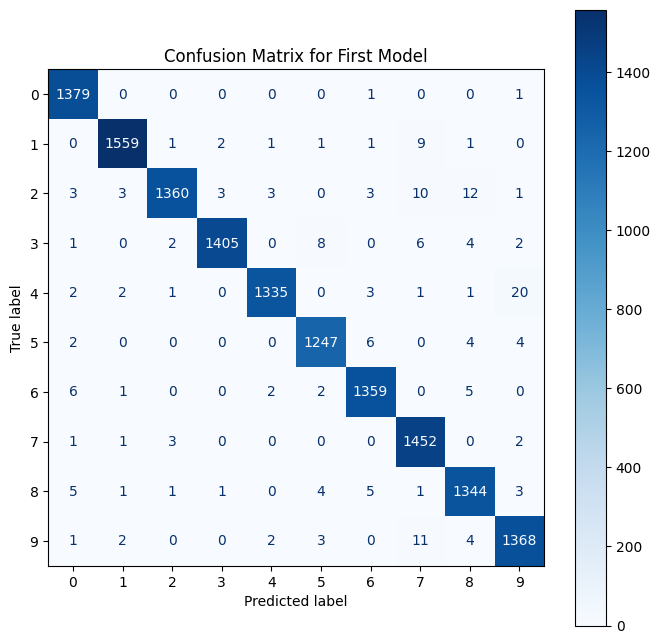

In [23]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues")
plt.title("Confusion Matrix for First Model")
plt.show()

### What did you find?

Look at the off-diagonal cells with the largest counts. Which pairs of digits does your model confuse most often? Some pairs are visually similar and are commonly mixed up.


*The model achieves high overall accuracy, but consistently confuses (4,9) and (7,9) [e.g., mistaking 4 for 9 a total of 15 times]. This happens because of their strong stuctural similarities in handwriting. For instance, a 4 with a closed top can look geometrically  identical to a 9,wlile a curved 7 can easily mimic the loop of a 9.*

## Part D. One change

Now answer the second half of the central question: does one change to the model move the mistakes?

Choose **one** change from the two below. Do not make both at once, or you will not know which one caused any difference you see.

- **Option A: a deeper network.** Before the Flatten layer, add `Conv2D(64, (3, 3), activation="relu")` followed by `MaxPooling2D((2, 2))`. This lets the network learn more detailed patterns.
- **Option B: stronger regularisation.** Raise the Dropout rate from 0.3 to 0.5. This makes the network rely less on any single feature.

**Before you run anything, write down your prediction:** will your chosen change raise the test accuracy, and will it reduce the confusion between the pairs you found in Part C? Note it here.

Neural-network training contains some randomness. A very small difference in accuracy does not necessarily show that one model is genuinely better. Look at the size of the difference and at the specific mistakes, not only at which accuracy is larger.

*I predict that adding another conv and max-pooling block (Option A) will improve local feature extraction and boost test accuracy. This finer detail should significantly reduce confusion between visually similar pairs like(4,9) and (7,9) by better isolating loops and intersections.*

In [24]:
keras.utils.set_random_seed(42)

model2 = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping2 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history2 = model2.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    callbacks=[early_stopping2]
)

Epoch 1/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 35s 85ms/step - accuracy: 0.9163 - loss: 0.2832 - val_accuracy: 0.9773 - val_loss: 0.0787
Epoch 2/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - accuracy: 0.9759 - loss: 0.0785 - val_accuracy: 0.9805 - val_loss: 0.0600
Epoch 3/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 42s 84ms/step - accuracy: 0.9831 - loss: 0.0555 - val_accuracy: 0.9839 - val_loss: 0.0482
Epoch 4/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 34s 86ms/step - accuracy: 0.9864 - loss: 0.0445 - val_accuracy: 0.9871 - val_loss: 0.0405
Epoch 5/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 41s 87ms/step - accuracy: 0.9881 - loss: 0.0376 - val_accuracy: 0.9873 - val_loss: 0.0426
Epoch 6/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.9892 - loss: 0.0335 - val_accuracy: 0.9871 - val_loss: 0.0383
Epoch 7/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 37s 76ms/step - accuracy: 0.9908 - loss: 0.0288 - val_accuracy: 0.9886 - val_loss: 0.0400
Epoch 8/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - accuracy: 0.9915 - loss: 0.0256 - 

438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9894 - loss: 0.0353
First Model Test Accuracy:  0.9863
Second Model Test Accuracy: 0.9894
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


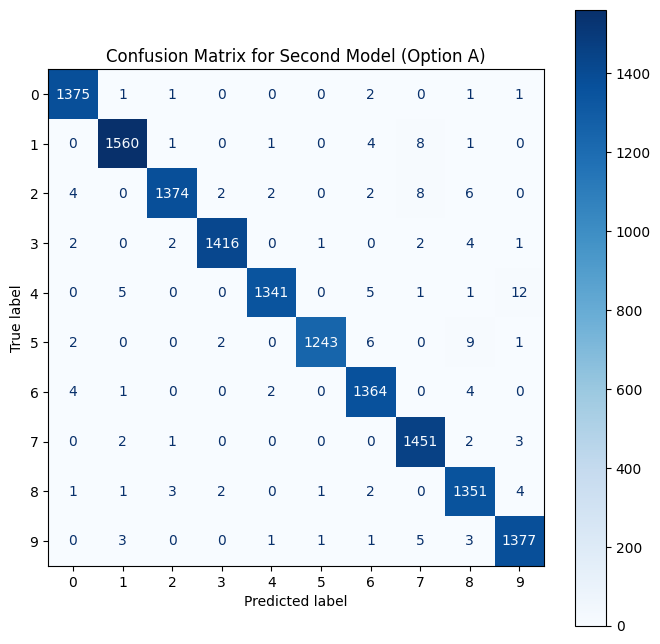

In [26]:
test_loss2, test_accuracy2 = model2.evaluate(X_test, y_test)
print(f"First Model Test Accuracy:  {test_accuracy:.4f}")
print(f"Second Model Test Accuracy: {test_accuracy2:.4f}")

y_pred_probs2 = model2.predict(X_test)
y_pred2 = y_pred_probs2.argmax(axis=1)

cm2 = confusion_matrix(y_test, y_pred2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2)

fig, ax = plt.subplots(figsize=(8, 8))
disp2.plot(ax=ax, cmap="Blues")
plt.title("Confusion Matrix for Second Model (Option A)")
plt.show()

### Ethical considerations

A digit reader does not perform equally well for everyone. Handwriting varies by age, country, and schooling, and a model trained mostly on one style may read another less reliably.

Putting this model into a real reading pipeline carries significant operational and ethical risks. Automated number readers do not guarantee equal performance across all populations. Handwriting skills are shaped by culture, age and schooling, a neural network primarily exposed to one specific demographic will inherently falter on others. Integrating this software into live automated workflows intoduces major ethical and operational vunerabilities. If the data is biased toward a single group, individuals who write numbers differently- like crossing a 7 or making a loopless 9- will face constant misclassifications. Whether it results in misdirected financial transfers or lost postal mail, these confident but flawed predictions can cause serious damage, falling heavily on underrepresented demographics.

## Wrapping up

- Our first model made most of its mistakes on visually similar pairs, specifically confusing (4, 9) and (7, 9).
- The prediction in Part D was correct: adding a second convolutional block (Option A) improved spatial feature extraction, leading to a rise in overall test accuracy from **98.63%** to **98.94%**.
- Looking closely at the confusion matrices:
  - The confusion of **mistaking 4 for 9** went down from **20** to **12** occurrences.
  - The confusion of **mistaking 7 for 9** went down from **23** to **12** occurrences.
- The fact that a single network adjustment nearly halved these systematic flaws, confirms that deeper models are crucial for resolving complex visual ambiguites.